# Proyek Klasifikasi Gambar: Garbage Dataset
- **Nama:** Nasywa Agiyan Nisa
- **Email:** nasywaagiyann@gmail.com
- **ID Dicoding:** MC200D5X2372

## Import Semua Packages/Library yang Digunakan

In [ ]:
# Standard Libraries
import os
import random
import shutil
import glob
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import imread

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                     GlobalAveragePooling2D, Dense,
                                     BatchNormalization, Dropout)
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications import ResNet101V2, DenseNet201
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


## Data Preparation

### Data Loading

In [ ]:
# Mengunggah file dari komputer lokal ke Google Colab
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nasywaagiyann","key":"4af7641d0b2ac0c08333df8ee8a0f0c5"}'}

In [ ]:
# Membuat folder .kaggle dan memindahkan kaggle.json ke sana untuk autentikasi API Kaggle
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json


In [ ]:
# Mengunduh dataset dari Kaggle menggunakan Kaggle API
!kaggle datasets download -d sumn2u/garbage-classification-v2

Dataset URL: https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2
License(s): MIT


In [ ]:
# Mengekstrak file ZIP dataset ke folder 'garbage_dataset'
with zipfile.ZipFile("garbage-classification-v2.zip", 'r') as zip_ref:
    zip_ref.extractall("garbage_dataset")


In [ ]:
# Menyimpan path ke folder dataset gambar
dataset_dir = "garbage_dataset/garbage-dataset"


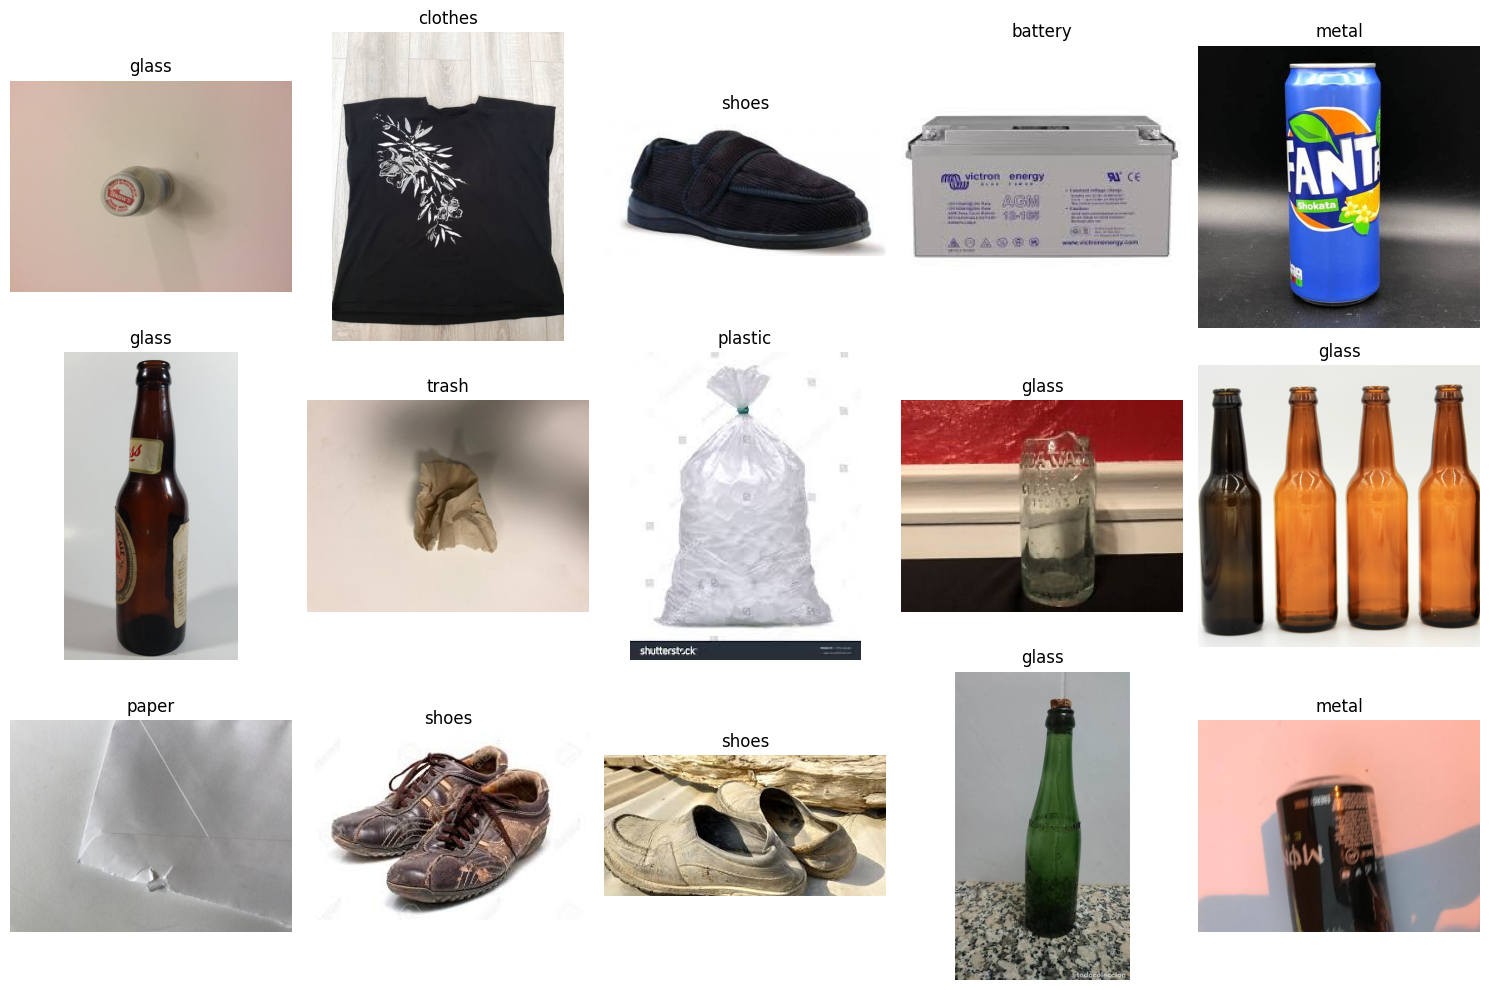

In [ ]:
# Ambil semua path gambar dari subfolder di dataset_dir
image_paths = glob.glob(os.path.join(dataset_dir, "*", "*"))

# Acak dan ambil 15 gambar
random_images = random.sample(image_paths, 15)

# Visualisasi gambar
plt.figure(figsize=(15, 10))
for i, image_path in enumerate(random_images):
    plt.subplot(3, 5, i + 1)
    img = imread(image_path)
    plt.imshow(img)
    plt.title(os.path.basename(os.path.dirname(image_path)))
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Menghitung jumlah kelas dengan menghitung jumlah folder di dalam dataset_dir
num_classes = len(os.listdir(dataset_dir))
print(f"Number of class: {num_classes}")


Number of class: 10


### Data Preprocessing

#### Split Dataset

In [ ]:
def split_test_set(dataset_dir, output_test_dir, test_ratio=0.1):
    os.makedirs(output_test_dir, exist_ok=True)
    for class_name in os.listdir(dataset_dir):
        class_dir = os.path.join(dataset_dir, class_name)
        if not os.path.isdir(class_dir): continue

        images = os.listdir(class_dir)
        test_size = int(len(images) * test_ratio)
        test_images = random.sample(images, test_size)

        test_class_dir = os.path.join(output_test_dir, class_name)
        os.makedirs(test_class_dir, exist_ok=True)

        for img in test_images:
            src = os.path.join(class_dir, img)
            dst = os.path.join(test_class_dir, img)
            shutil.move(src, dst)

    print("Test set dipindahkan ke:", output_test_dir)

# Memindahkan 10% data ke folder test
split_test_set('garbage_dataset/garbage-dataset', 'garbage_dataset/garbage-test', test_ratio=0.1)


Test set dipindahkan ke: garbage_dataset/garbage-test


In [ ]:
# Path utama dataset
dataset_dir = 'garbage_dataset/garbage-dataset'
test_dir = 'garbage_dataset/garbage-test'

# Normalisasi dan pembagian data (train & validation)
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Generator untuk data pelatihan (training)
train_gen = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Generator untuk data validasi (validation)
val_gen = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

# Normalisasi untuk test set
test_datagen = ImageDataGenerator(rescale=1./255)

# Generator untuk data test
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)


Found 14235 images belonging to 10 classes.
Found 3555 images belonging to 10 classes.
Found 1972 images belonging to 10 classes.


In [ ]:
# Mengambil mapping dari nama kelas ke indeks numerik
label_dict = dict(train_gen.class_indices)

# Menampilkan dictionary yang berisi pasangan label dan indeks
print(label_dict)


{'battery': 0, 'biological': 1, 'cardboard': 2, 'clothes': 3, 'glass': 4, 'metal': 5, 'paper': 6, 'plastic': 7, 'shoes': 8, 'trash': 9}


## Modelling

In [ ]:
# Load base model
base_model = ResNet101V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Build Sequential model
model_Resnet = Sequential([
    Input(shape=(224, 224, 3)),
    base_model,

    # Tambahkan Conv2D dan MaxPooling2D setelah base model
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(10, activation='softmax')
])

# Print model summary
model_Resnet.summary()


171317808/171317808 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet101v2 (Functional)        │ (None, 7, 7, 2048)     │    42,626,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 256)      │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,858,250 (182.56 MB)

 Trainable params: 5,230,026 (19.95 MB)

 Non-trainable params: 42,628,224 (162.61 MB)

## Evaluasi dan Visualisasi

In [ ]:
# Import optimizers dari tensorflow.keras.optimizers
from tensorflow.keras import optimizers

# Definisikan optimizer AdamW dengan learning rate 0.0001
optimizer = optimizers.AdamW(learning_rate=1e-4)

# Compile model dengan loss function categorical crossentropy
model_Resnet.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

# Callback untuk mengatur learning rate secara dinamis saat val_loss stagnan
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Callback untuk menghentikan training lebih awal jika tidak ada peningkatan pada val_loss
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Training model selama maksimum 7 epoch dengan validasi dan dua callback
history_Resnet = model_Resnet.fit(
    train_gen,
    epochs=4,
    validation_data=val_gen,
    callbacks=[lr_scheduler, early_stop]
)


Epoch 1/4
890/890 ━━━━━━━━━━━━━━━━━━━━ 5193s 6s/step - accuracy: 0.5053 - loss: 1.5212 - val_accuracy: 0.8582 - val_loss: 0.4407 - learning_rate: 1.0000e-04
Epoch 2/4
890/890 ━━━━━━━━━━━━━━━━━━━━ 5105s 6s/step - accuracy: 0.8455 - loss: 0.5252 - val_accuracy: 0.8993 - val_loss: 0.3240 - learning_rate: 1.0000e-04
Epoch 3/4
890/890 ━━━━━━━━━━━━━━━━━━━━ 5109s 6s/step - accuracy: 0.8975 - loss: 0.3639 - val_accuracy: 0.8973 - val_loss: 0.3161 - learning_rate: 1.0000e-04
Epoch 4/4
890/890 ━━━━━━━━━━━━━━━━━━━━ 5093s 6s/step - accuracy: 0.9254 - loss: 0.2592 - val_accuracy: 0.9218 - val_loss: 0.2489 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 4.


In [ ]:
# Mendapatkan jumlah batch pada data uji
num_batches = len(test_generator)

# Melakukan prediksi hanya pada batch penuh
y_pred_cnn = model_Resnet.predict(test_generator, steps=num_batches)

# Mengambil label sebenarnya
y_true = test_generator.classes[:len(y_pred_cnn)]

# Import accuracy_score dari sklearn.metrics
from sklearn.metrics import accuracy_score

# Menghitung akurasi
y_pred_classes = np.argmax(y_pred_cnn, axis=1)
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

124/124 ━━━━━━━━━━━━━━━━━━━━ 562s 4s/step
Test Accuracy: 92.14%


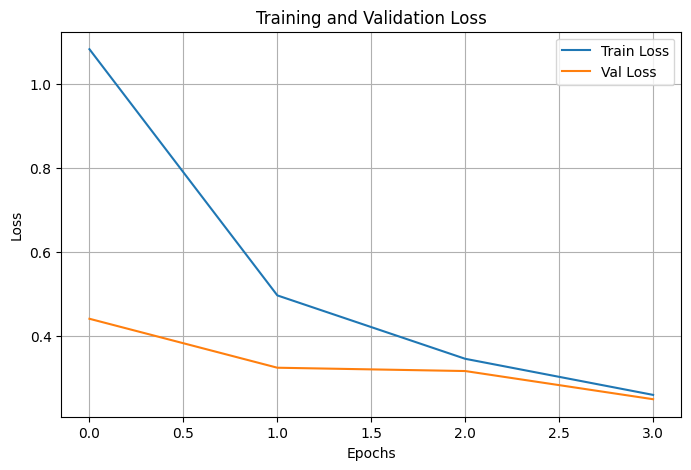

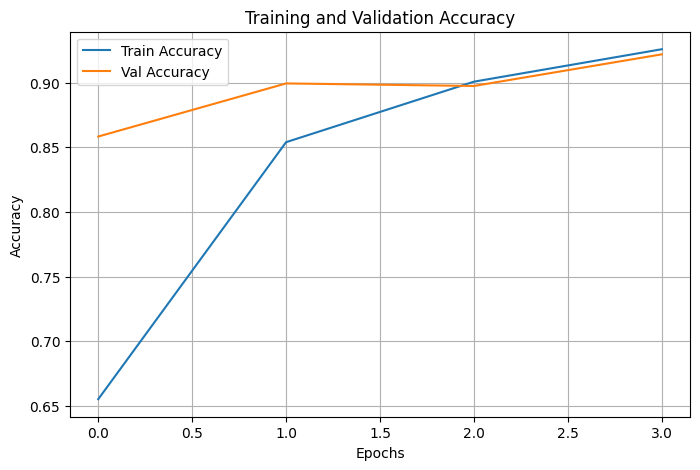

In [ ]:
# Plotting Loss
plt.figure(figsize=(8, 5))
plt.plot(history_Resnet.history['loss'], label='Train Loss')
plt.plot(history_Resnet.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_Resnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_Resnet.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


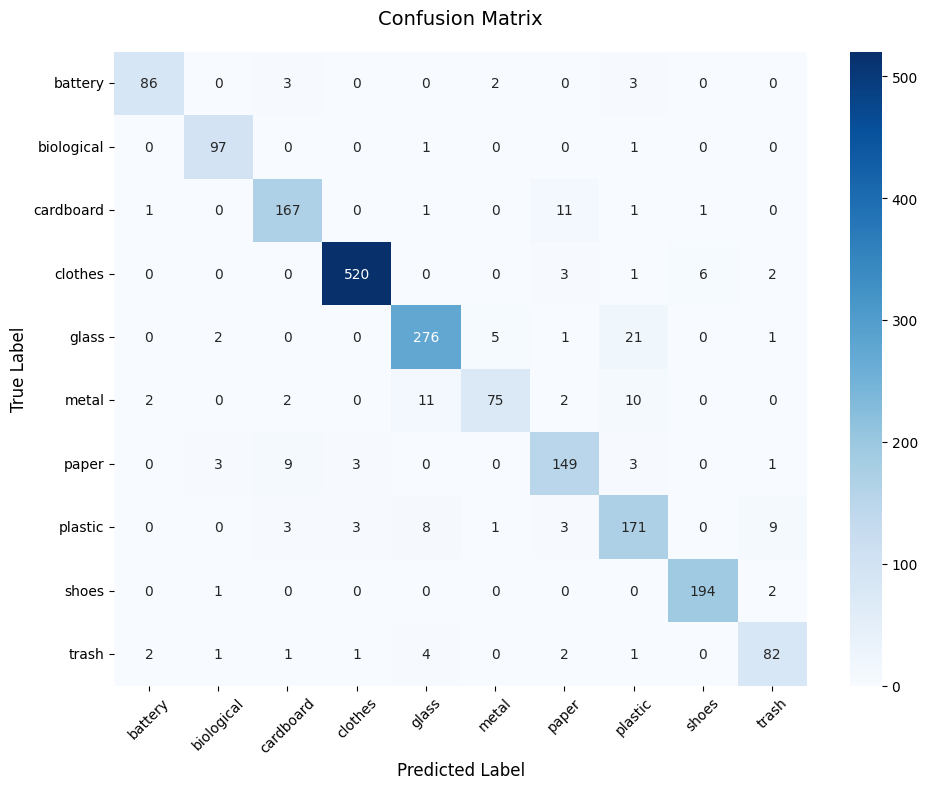

In [ ]:
# Menampilkan confusion matrix sebagai heatmap
from sklearn.metrics import confusion_matrix # Import confusion_matrix

plt.figure(figsize=(10, 8))

# Hitung confusion matrix menggunakan y_true dan y_pred_classes
cm_cnn = confusion_matrix(y_true, y_pred_classes) # Mendefinisikan cm_cnn

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(test_generator.class_indices.keys()),
            yticklabels=list(test_generator.class_indices.keys()))
plt.title('Confusion Matrix', fontsize=14, pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

## Konversi Model

In [ ]:
# Menyimpan Model ke SavedModel
model_Resnet.export('saved_model')


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_377')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  137179390581584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137179390579472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137179390579856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137179390580432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137179390581008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137179390580240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137179390578896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137179368567056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137179368565520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137179368566864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13717936856628

### **TFLITE**

In [ ]:
path_savedmodel = 'saved_model'
path_tfliteouput = 'tflite/model.tflite'
path_labeloutput = 'tflite/label.txt'

os.makedirs(os.path.dirname(path_tfliteouput), exist_ok=True)

In [ ]:
converter = tf.lite.TFLiteConverter.from_saved_model(path_savedmodel)
tflite_model = converter.convert()

# Simpan model .tflite
with open(path_labeloutput, 'wb') as f:
    f.write(tflite_model)
print(f"Model TFLite berhasil disimpan di: {path_labeloutput}")

# Ambil label kelas dari train_gen.class_indices
label_dict = train_gen.class_indices

# Simpan label ke file
with open(path_labeloutput, 'w') as f:
    for label in label_dict:
        f.write(f"{label}\n")
print(f"Label kelas berhasil disimpan di: {path_labeloutput}")

Model TFLite berhasil disimpan di: tflite/label.txt
Label kelas berhasil disimpan di: tflite/label.txt


### **TFJS**

In [ ]:
!pip install tensorflowjs
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    saved_model \
    tfjs_model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.31.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
2025-04-27 21:12:53.576543: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745788373.650115   86425 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:174

## Inference (Optional)

In [ ]:
converter = tf.lite.TFLiteConverter.from_saved_model(path_savedmodel)
tflite_model = converter.convert()

with open(path_tfliteouput, 'wb') as f:
    f.write(tflite_model)
print(f"Model TFLite berhasil disimpan di: {path_tfliteouput}")

# Ambil label kelas dari train_gen.class_indices
label_dict = train_gen.class_indices

# Simpan label ke file
with open(path_labeloutput, 'w') as f:
    for label in label_dict:
        f.write(f"{label}\n")
print(f"Label kelas berhasil disimpan di: {path_labeloutput}")

Model TFLite berhasil disimpan di: tflite/model.tflite
Label kelas berhasil disimpan di: tflite/label.txt


Jumlah gambar ditemukan: 1972


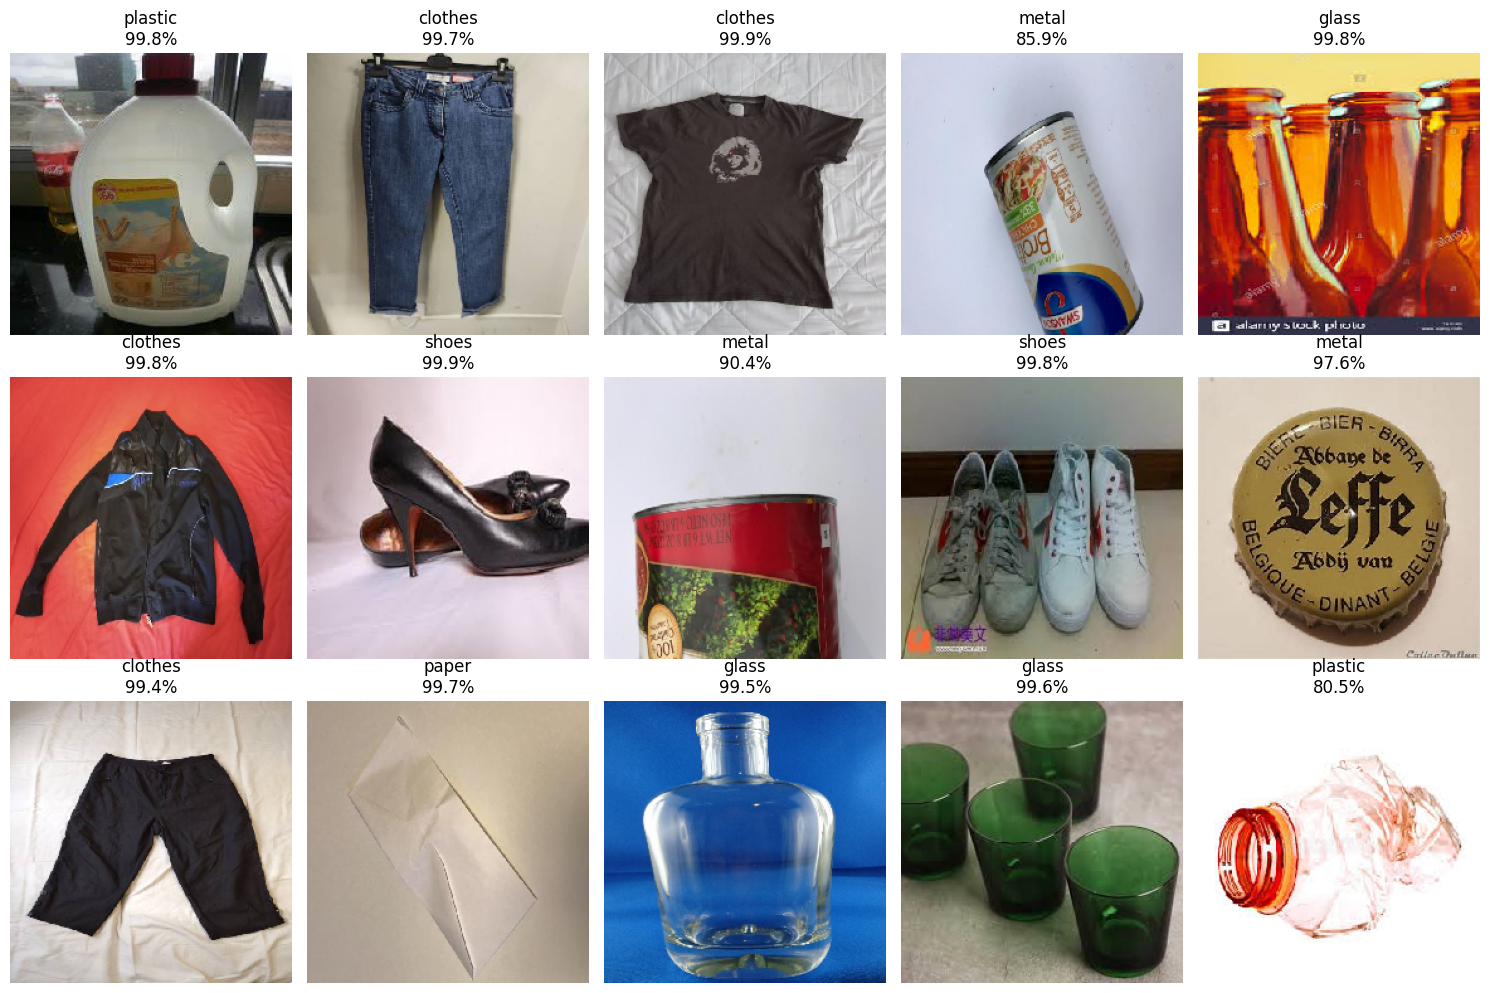

In [ ]:
# Path
test_dir = 'garbage_dataset/garbage-test'
tflite_model_path = 'tflite/model.tflite'
label_path = 'tflite/label.txt'

# Load label dari label.txt
with open(label_path, 'r') as f:
    class_names = [line.strip() for line in f.readlines()]

image_paths = glob.glob(os.path.join(test_dir, "*", "*"))

if len(image_paths) == 0:
    print("Tidak ditemukan gambar di garbage_dataset/garbage-test.")
else:
    print(f"Jumlah gambar ditemukan: {len(image_paths)}")

    # Ambil 15 gambar acak
    random_images = random.sample(image_paths, 15)

    # Load TFLite model
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Visualisasi hasil prediksi
    plt.figure(figsize=(15, 10))

    for i, image_path in enumerate(random_images):
        # Load dan preprocess gambar
        img = load_img(image_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0).astype(np.float32)

        # Set input ke interpreter
        interpreter.set_tensor(input_details[0]['index'], img_array)
        interpreter.invoke()

        # Ambil output prediksi
        output_data = interpreter.get_tensor(output_details[0]['index'])
        predicted_idx = np.argmax(output_data)
        predicted_class = class_names[predicted_idx]
        confidence = np.max(output_data) * 100

        # Plot gambar dan hasil prediksi
        plt.subplot(3, 5, i + 1)
        plt.imshow(img)
        plt.title(f"{predicted_class}\n{confidence:.1f}%")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
